# Image Dataset Pipeline Notebook

## Pertanyaan Bisnis

Jenis masalah kerusakan kulit apa yang paling dominan pada dataset citra kulit dan tingkat keparahannya berdasarkan hasil analisis dataset untuk mendukung analisis kesehatan kulit selama periode pengembangan project?

## 1. Import Library

In [11]:

import os
import shutil
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

plt.style.use('default')

print("Library berhasil diimport")


Library berhasil diimport


## 2. Tentukan Path Dataset

In [12]:

# Ganti sesuai lokasi dataset kamu
DATASET_PATH = r"D:/studi independen/ANALISIS_DATA_CPTN/Data capston project"

# Folder output clean dataset
OUTPUT_PATH = "clean_data"

DATASET_PATH


'D:/studi independen/ANALISIS_DATA_CPTN/Data capston project'

## 3. Membaca Dataset Gambar

In [13]:

data = []

valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')

for severity in os.listdir(DATASET_PATH):

    severity_path = os.path.join(DATASET_PATH, severity)

    if os.path.isdir(severity_path):

        for disease in os.listdir(severity_path):

            disease_path = os.path.join(severity_path, disease)

            if os.path.isdir(disease_path):

                for file in os.listdir(disease_path):

                    if file.lower().endswith(valid_extensions):

                        filepath = os.path.join(disease_path, file)

                        try:
                            with Image.open(filepath) as img:

                                width, height = img.size

                                data.append({
                                    'severity': severity,
                                    'disease': disease,
                                    'filename': file,
                                    'filepath': filepath,
                                    'width': width,
                                    'height': height,
                                    'format': img.format,
                                    'mode': img.mode
                                })

                        except:
                            print(f"Corrupt image: {filepath}")

df = pd.DataFrame(data)

print("Total gambar:", len(df))
df.head()


Total gambar: 8837


,severity,disease,filename,filepath,width,height,format,mode
0,Normal,healthy skin,17053005206957139408735922636266 - Gabriel Mar...,D:/studi independen/ANALISIS_DATA_CPTN/Data ca...,4080,2296,JPEG,RGB
1,Normal,healthy skin,17053016125375393346221463682922 - Billy Endry...,D:/studi independen/ANALISIS_DATA_CPTN/Data ca...,3000,4000,JPEG,RGB
2,Normal,healthy skin,20240115_115549.jpg,D:/studi independen/ANALISIS_DATA_CPTN/Data ca...,4000,3000,JPEG,RGB
3,Normal,healthy skin,20240115_115615.jpg,D:/studi independen/ANALISIS_DATA_CPTN/Data ca...,4000,3000,JPEG,RGB
4,Normal,healthy skin,20240115_120344.jpg,D:/studi independen/ANALISIS_DATA_CPTN/Data ca...,4000,3000,JPEG,RGB


## 3b. Assessing Data
Mengevaluasi kualitas dan struktur dataset sebelum masuk ke tahap cleaning.

In [14]:
# Struktur dan tipe data
print("Shape dataset:", df.shape)
print()
df.info()

Shape dataset: (8837, 8)

<class 'pandas.DataFrame'>
RangeIndex: 8837 entries, 0 to 8836
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   severity  8837 non-null   str  
 1   disease   8837 non-null   str  
 2   filename  8837 non-null   str  
 3   filepath  8837 non-null   str  
 4   width     8837 non-null   int64
 5   height    8837 non-null   int64
 6   format    8837 non-null   str  
 7   mode      8837 non-null   str  
dtypes: int64(2), str(6)
memory usage: 2.3 MB


In [15]:
# Statistik deskriptif kolom numerik
df.describe()

,width,height
count,8837.000000,8837.000000
mean,644.691864,583.465203
std,311.513253,339.799308
min,194.000000,122.000000
25%,512.000000,472.000000
50%,600.000000,512.000000
75%,720.000000,512.000000
max,4160.000000,4608.000000


In [16]:
# Distribusi format dan mode warna
print("Format gambar:")
print(df['format'].value_counts())
print()
print("Mode warna:")
print(df['mode'].value_counts())

Format gambar:
format
JPEG    8592
PNG      245
Name: count, dtype: int64

Mode warna:
mode
RGB    8837
Name: count, dtype: int64


In [17]:
# Cek distribusi label sebelum cleaning
print("Distribusi Severity:")
print(df['severity'].value_counts())
print()
print("Distribusi Disease:")
print(df['disease'].value_counts())

Distribusi Severity:
severity
Terparah    3911
Ringan      2029
Sedang      2025
Normal       872
Name: count, dtype: int64

Distribusi Disease:
disease
Seborrheic Keratoses and other Benign Tumors             1399
Melanoma                                                 1277
Basal Cell Carcinoma (BCC)                               1235
Benign Keratosis-like Lesions (BKL)                      1214
Psoriasis pictures Lichen Planus and related diseases    1178
healthy skin                                              872
Melasma                                                   732
hyperpigmentation                                         700
Solar Lentigo                                             115
Sunburn                                                   115
Name: count, dtype: int64


## 4. Simpan Metadata Dataset

In [18]:

df.to_csv("metadata_raw_dataset.csv", index=False)

print("metadata_raw_dataset.csv berhasil dibuat")


metadata_raw_dataset.csv berhasil dibuat


## 5. Data Cleaning

### Cek Missing Values

In [19]:

df.isnull().sum()


severity    0
disease     0
filename    0
filepath    0
width       0
height      0
format      0
mode        0
dtype: int64

### Cek Duplicate Filepath

In [20]:

duplicate_count = df.duplicated(subset=['filepath']).sum()

print("Jumlah duplicate:", duplicate_count)


Jumlah duplicate: 0


### Hapus Duplicate

In [21]:

df = df.drop_duplicates(subset=['filepath'])

print("Dataset setelah remove duplicate:", len(df))


Dataset setelah remove duplicate: 8837


### Cek Ukuran Gambar

In [22]:

df[['width','height']].describe()


,width,height
count,8837.000000,8837.000000
mean,644.691864,583.465203
std,311.513253,339.799308
min,194.000000,122.000000
25%,512.000000,472.000000
50%,600.000000,512.000000
75%,720.000000,512.000000
max,4160.000000,4608.000000


### Visualisasi Resolusi

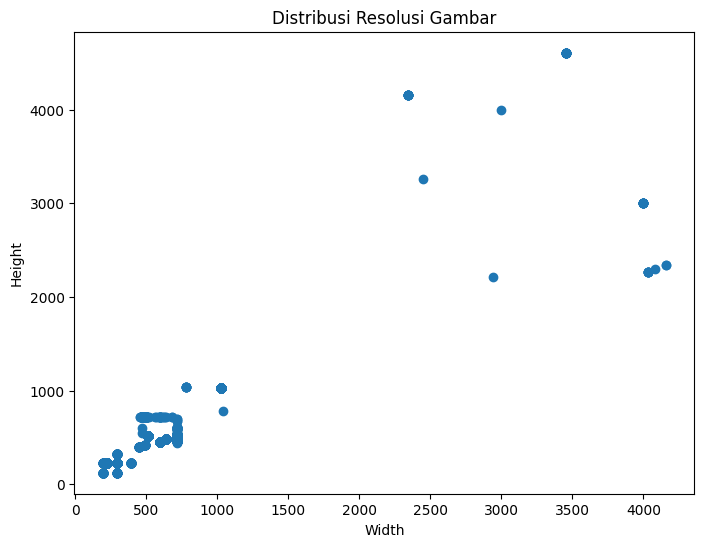

In [23]:

plt.figure(figsize=(8,6))

plt.scatter(df['width'], df['height'])

plt.xlabel("Width")
plt.ylabel("Height")

plt.title("Distribusi Resolusi Gambar")

plt.show()


### Resize dan Convert RGB

In [24]:

TARGET_SIZE = (224, 224)

cleaned_data = []

for idx, row in df.iterrows():

    try:
        img = Image.open(row['filepath'])

        img = img.convert("RGB")

        img = img.resize(TARGET_SIZE)

        cleaned_data.append({
            'severity': row['severity'],
            'disease': row['disease'],
            'filename': row['filename'],
            'image': img
        })

    except:
        print("Failed:", row['filepath'])

print("Total cleaned images:", len(cleaned_data))


Total cleaned images: 8837


## 5b. Data Dictionary
Dokumentasi setiap kolom pada dataset metadata yang digunakan dalam proyek ini.

In [25]:
data_dictionary = {
    'Kolom': [
        'severity', 'disease', 'filename', 'filepath',
        'width', 'height', 'format', 'mode'
    ],
    'Tipe Data': [
        'string', 'string', 'string', 'string',
        'integer', 'integer', 'string', 'string'
    ],
    'Deskripsi': [
        'Tingkat keparahan penyakit kulit: Normal / Ringan / Sedang / Terparah',
        'Nama jenis penyakit/kondisi kulit (label kelas untuk model)',
        'Nama file gambar (unik per folder disease)',
        'Path lengkap file gambar di sistem lokal',
        'Lebar gambar dalam piksel sebelum resize',
        'Tinggi gambar dalam piksel sebelum resize',
        'Format file gambar: JPEG, PNG, WEBP',
        'Mode warna gambar: RGB, RGBA, atau L (grayscale)'
    ],
    'Contoh Nilai': [
        'Terparah, Normal, Ringan, Sedang',
        'Melanoma, Eczema, Psoriasis',
        'img_001.jpg',
        'D:/Data/Terparah/Melanoma/img.jpg',
        '224, 512, 1024',
        '224, 768',
        'JPEG, PNG',
        'RGB, RGBA'
    ],
    'Catatan': [
        '4 kategori unik',
        '10 kelas penyakit unik',
        'Nama file asli dari dataset',
        'Path absolut di mesin lokal',
        'Piksel asli, belum di-resize',
        'Piksel asli, belum di-resize',
        'Mayoritas JPEG',
        'Dikonversi ke RGB sebelum training'
    ]
}

dd_df = pd.DataFrame(data_dictionary)
print("DATA DICTIONARY - Skin Disease Image Dataset")
print("=" * 60)
dd_df

DATA DICTIONARY - Skin Disease Image Dataset


,Kolom,Tipe Data,Deskripsi,Contoh Nilai,Catatan
0,severity,string,Tingkat keparahan penyakit kulit: Normal / Rin...,"Terparah, Normal, Ringan, Sedang",4 kategori unik
1,disease,string,Nama jenis penyakit/kondisi kulit (label kelas...,"Melanoma, Eczema, Psoriasis",10 kelas penyakit unik
2,filename,string,Nama file gambar (unik per folder disease),img_001.jpg,Nama file asli dari dataset
3,filepath,string,Path lengkap file gambar di sistem lokal,D:/Data/Terparah/Melanoma/img.jpg,Path absolut di mesin lokal
4,width,integer,Lebar gambar dalam piksel sebelum resize,"224, 512, 1024","Piksel asli, belum di-resize"
5,height,integer,Tinggi gambar dalam piksel sebelum resize,"224, 768","Piksel asli, belum di-resize"
6,format,string,"Format file gambar: JPEG, PNG, WEBP","JPEG, PNG",Mayoritas JPEG
7,mode,string,"Mode warna gambar: RGB, RGBA, atau L (grayscale)","RGB, RGBA",Dikonversi ke RGB sebelum training


## 6. Exploratory Data Analysis (EDA)

### Distribusi Severity

In [26]:

severity_dist = df['severity'].value_counts()

severity_dist


severity
Terparah    3911
Ringan      2029
Sedang      2025
Normal       872
Name: count, dtype: int64

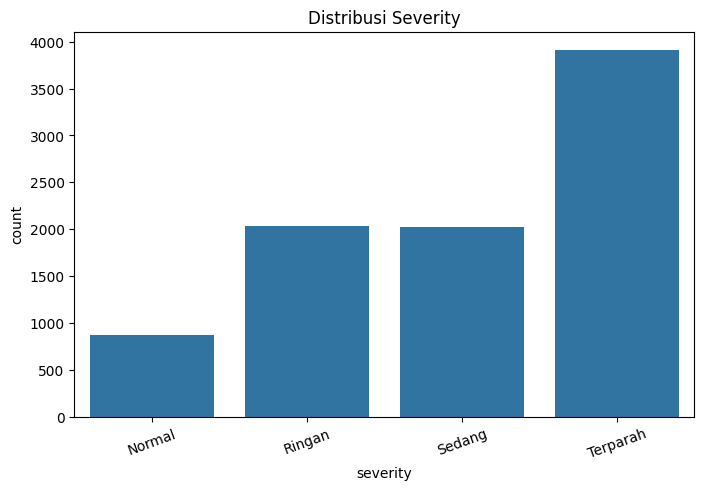

In [27]:

plt.figure(figsize=(8,5))

sns.countplot(data=df, x='severity')

plt.title("Distribusi Severity")

plt.xticks(rotation=20)

plt.show()


### Distribusi Disease

In [28]:

disease_dist = df['disease'].value_counts()

disease_dist.head(14)


disease
Seborrheic Keratoses and other Benign Tumors             1399
Melanoma                                                 1277
Basal Cell Carcinoma (BCC)                               1235
Benign Keratosis-like Lesions (BKL)                      1214
Psoriasis pictures Lichen Planus and related diseases    1178
healthy skin                                              872
Melasma                                                   732
hyperpigmentation                                         700
Solar Lentigo                                             115
Sunburn                                                   115
Name: count, dtype: int64

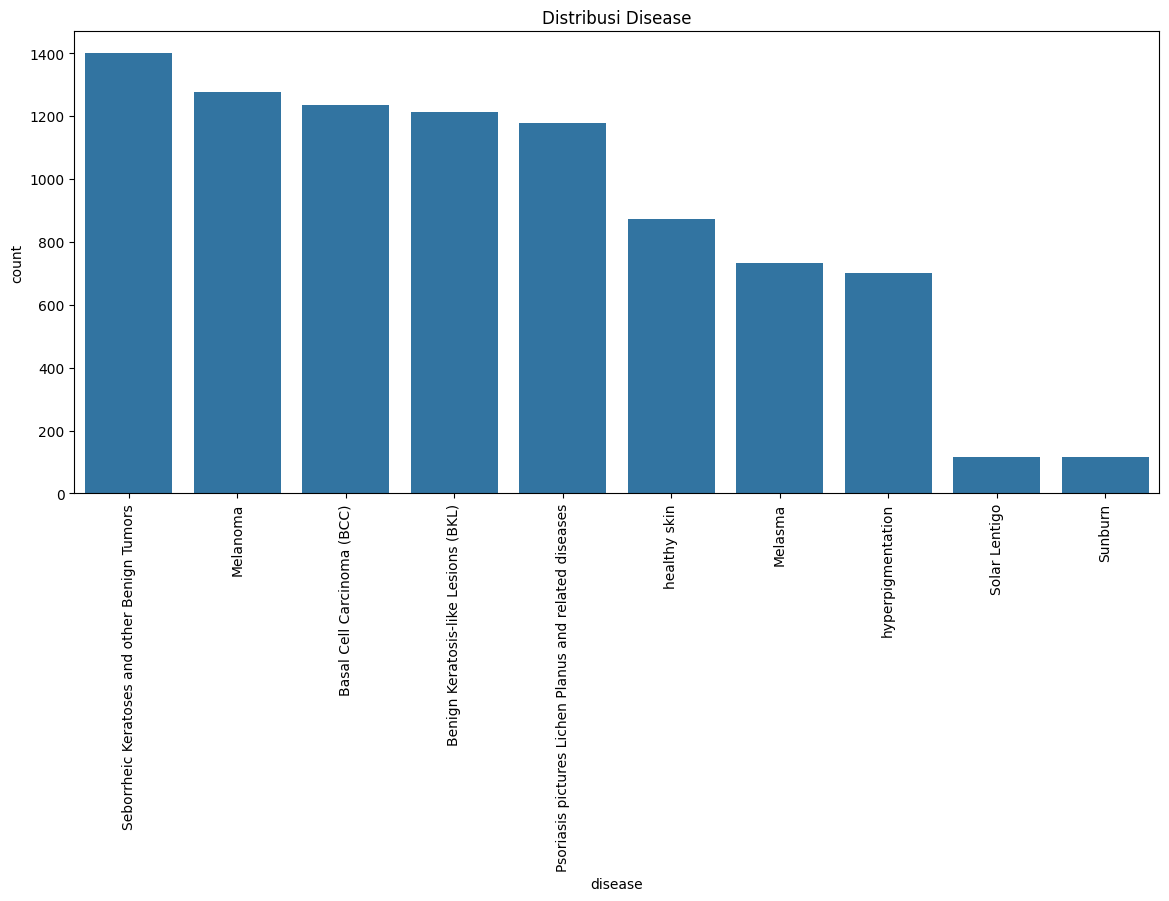

In [29]:

plt.figure(figsize=(14,6))

sns.countplot(data=df, x='disease',
              order=df['disease'].value_counts().index)

plt.xticks(rotation=90)

plt.title("Distribusi Disease")

plt.show()


### Analisis Imbalance Dataset

In [30]:

max_class = severity_dist.max()
min_class = severity_dist.min()

imbalance_ratio = round(max_class / min_class, 2)

print("Imbalance ratio:", imbalance_ratio, "x")

if imbalance_ratio <= 3:
    print("Dataset relatif seimbang")

elif imbalance_ratio <= 10:
    print("Dataset mulai imbalance")
    print("Disarankan augmentation dan class weighting")

else:
    print("Dataset sangat imbalance")
    print("Disarankan augmentation tambahan")


Imbalance ratio: 4.49 x
Dataset mulai imbalance
Disarankan augmentation dan class weighting


### Distribusi Disease per Kategori Severity

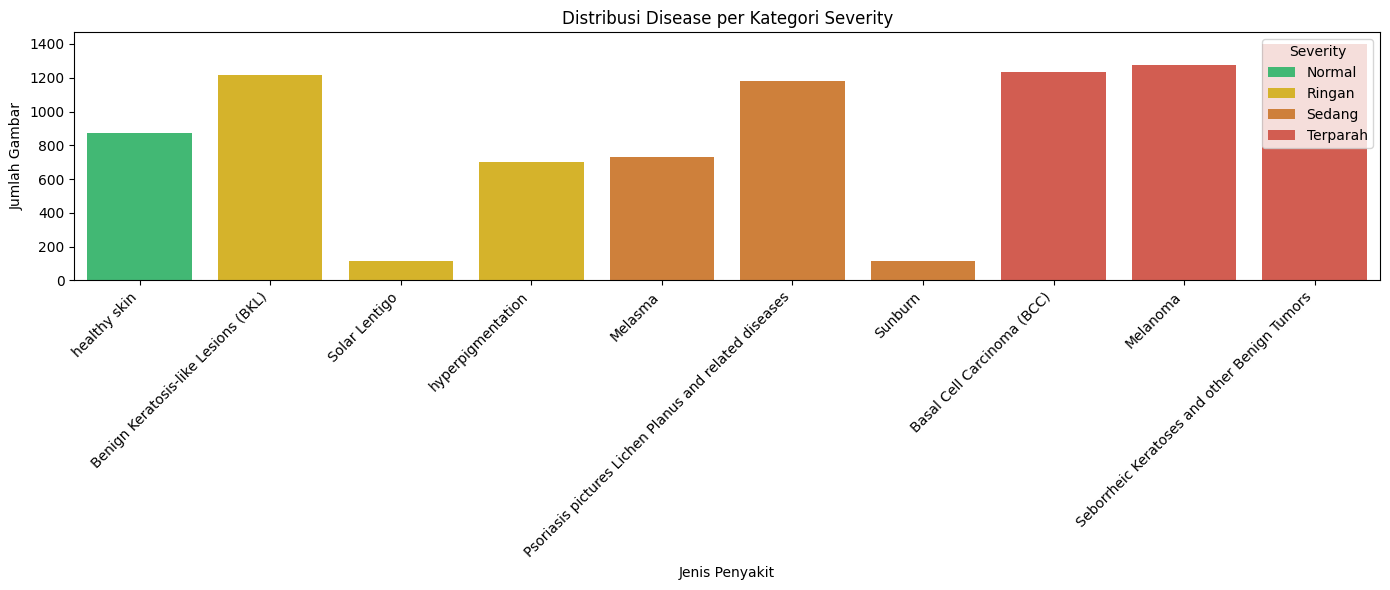

In [31]:
# Hitung jumlah gambar per disease dan severity
disease_severity = df.groupby(['severity', 'disease']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))

severity_order = ['Normal', 'Ringan', 'Sedang', 'Terparah']
palette = {'Normal': '#2ecc71', 'Ringan': '#f1c40f', 'Sedang': '#e67e22', 'Terparah': '#e74c3c'}

sns.barplot(data=disease_severity, x='disease', y='count', hue='severity',
            hue_order=severity_order, palette=palette)

plt.xticks(rotation=45, ha='right')
plt.title("Distribusi Disease per Kategori Severity")
plt.xlabel("Jenis Penyakit")
plt.ylabel("Jumlah Gambar")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

### Explanatory Analysis — Menjawab Pertanyaan Bisnis
Jenis penyakit kulit apa yang paling dominan dan bagaimana distribusi tingkat keparahannya?

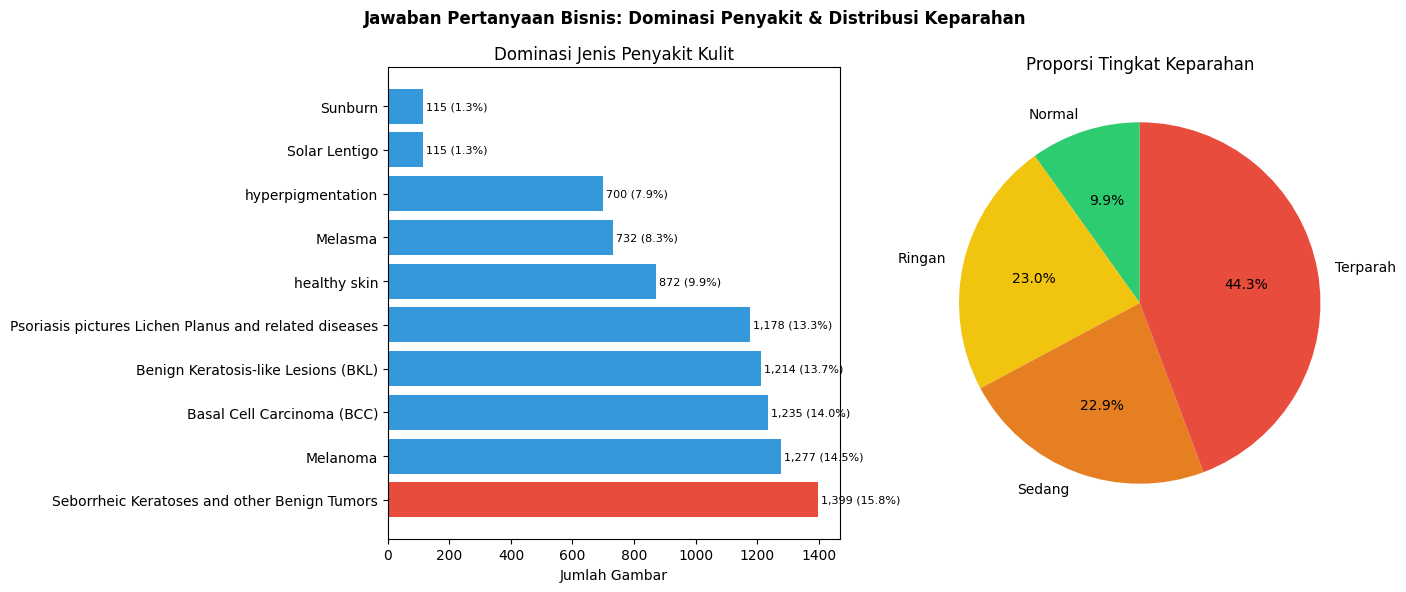

KESIMPULAN VISUAL:
  Penyakit paling dominan : Seborrheic Keratoses and other Benign Tumors (1,399 gambar, 15.8%)
  Severity paling dominan : Terparah (3,911 gambar, 44.3%)


In [32]:
# --- Jawaban Visual: Dominasi Penyakit ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Kiri: Top penyakit
disease_counts = df['disease'].value_counts()
colors_bar = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(disease_counts))]
axes[0].barh(disease_counts.index, disease_counts.values, color=colors_bar)
axes[0].set_title("Dominasi Jenis Penyakit Kulit")
axes[0].set_xlabel("Jumlah Gambar")
for i, val in enumerate(disease_counts.values):
    axes[0].text(val + 10, i, f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=8)

# Kanan: Proporsi Severity
severity_dist2 = df['severity'].value_counts().reindex(['Normal','Ringan','Sedang','Terparah'])
colors_pie = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
axes[1].pie(severity_dist2.values, labels=severity_dist2.index,
            autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1].set_title("Proporsi Tingkat Keparahan")

plt.suptitle("Jawaban Pertanyaan Bisnis: Dominasi Penyakit & Distribusi Keparahan",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("KESIMPULAN VISUAL:")
top_disease = disease_counts.index[0]
top_count = disease_counts.iloc[0]
top_sev = df['severity'].value_counts().index[0]
print(f"  Penyakit paling dominan : {top_disease} ({top_count:,} gambar, {top_count/len(df)*100:.1f}%)")
print(f"  Severity paling dominan : {top_sev} ({df['severity'].value_counts().iloc[0]:,} gambar, {df['severity'].value_counts().iloc[0]/len(df)*100:.1f}%)")

## 7. Visualisasi Sample Gambar

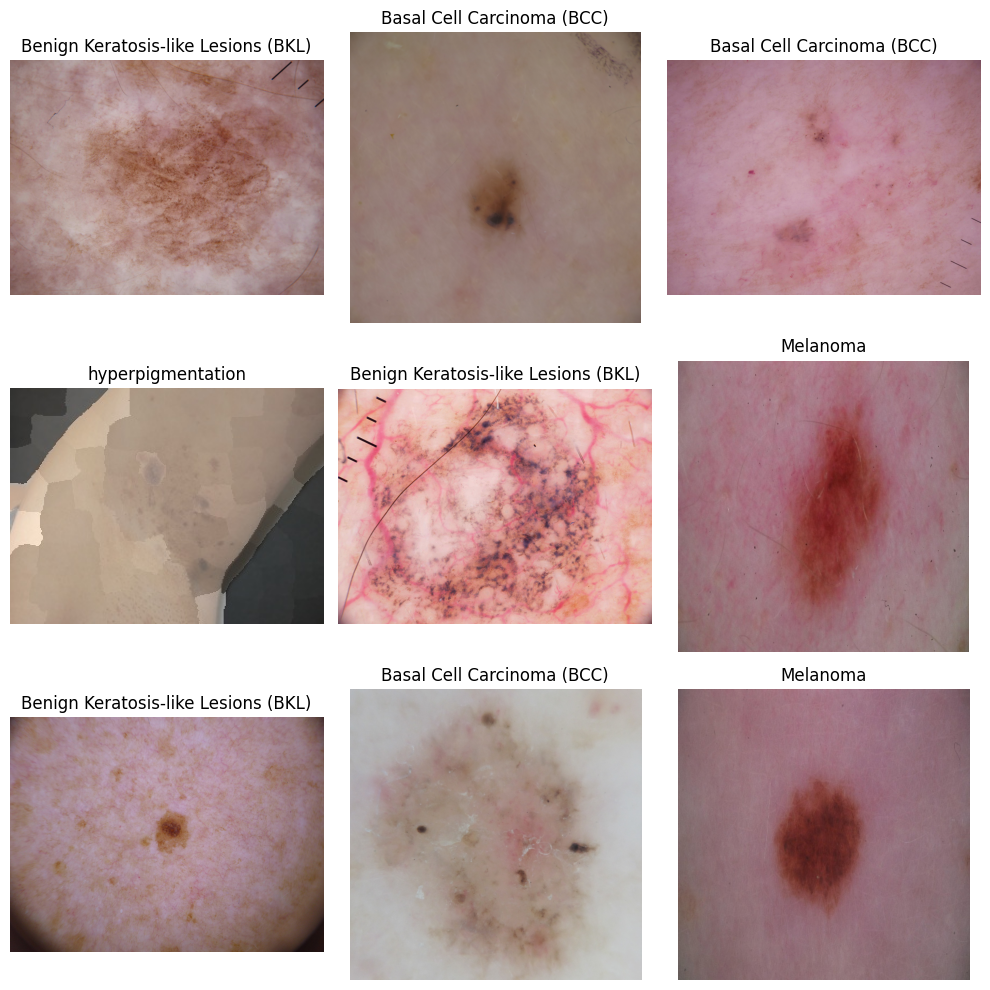

In [33]:

sample_df = df.sample(9)

fig, axes = plt.subplots(3,3, figsize=(10,10))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):

    img = Image.open(row['filepath'])

    ax.imshow(img)

    ax.set_title(row['disease'])

    ax.axis('off')

plt.tight_layout()

plt.show()


## 8. Split Train Validation Test

In [34]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['severity'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['severity'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 6185
Validation: 1326
Test: 1326


## 8b. Augmentasi Train Set per Disease
Menyeimbangkan data train ke **~1.200 gambar per disease** dengan augmentasi yang dikontrol.
Val dan Test set **tidak disentuh** agar evaluasi tetap objektif.

In [35]:
# Import library augmentasi
import random
from PIL import ImageEnhance, ImageFilter, ImageOps

print("Library augmentasi siap")


Library augmentasi siap


In [36]:
def augment_image(img):
    """
    Augmentasi gambar dengan intensitas terkontrol — anti overfitting.

    Prinsip:
    - Setiap transform bersifat PROBABILISTIK (tidak semuanya aktif sekaligus)
    - Range transform KECIL agar gambar tetap realistis secara klinis
    - Tidak ada vertical flip (gambar kulit terbalik tidak pernah ada di real data)
    - Rotasi pakai mean-fill, bukan black fill (hindari artefak border hitam)
    """
    # Horizontal flip (50%)
    if random.random() < 0.5:
        img = ImageOps.mirror(img)

    # Rotasi kecil, CONDITIONAL (40%, max ±15°)
    if random.random() < 0.4:
        angle = random.uniform(-15, 15)
        img = img.rotate(angle, expand=False, resample=Image.BILINEAR)
        # Ganti border hitam sisa rotasi dengan rata-rata warna gambar
        arr = np.array(img)
        mask = (arr == 0).all(axis=2)
        if mask.any():
            mean_color = tuple(int(c) for c in arr[~mask].mean(axis=0))
            arr[mask] = mean_color
            img = Image.fromarray(arr)

    # Brightness ringan (60%, 0.85–1.15)
    if random.random() < 0.6:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))

    # Contrast ringan (60%, 0.85–1.15)
    if random.random() < 0.6:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.15))

    # Saturation ringan (40%, 0.85–1.15)
    if random.random() < 0.4:
        img = ImageEnhance.Color(img).enhance(random.uniform(0.85, 1.15))

    # Gaussian blur sangat ringan (20%, max radius 0.7)
    # Blur tinggi merusak tekstur kulit yang penting untuk diagnosis
    if random.random() < 0.2:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 0.7)))

    # Noise kecil (15%, ±10 pixel)
    if random.random() < 0.15:
        arr = np.array(img).astype(np.int16)
        arr = np.clip(arr + np.random.randint(-10, 10, arr.shape), 0, 255).astype(np.uint8)
        img = Image.fromarray(arr)

    return img

print("Fungsi augment_image siap")


Fungsi augment_image siap


In [37]:
# ── Konfigurasi augmentasi ───────────────────────────────────────────
TARGET_PER_DISEASE = 1200   # target jumlah gambar per disease di train set
MAX_AUG_PER_IMAGE  = 15     # 1 gambar asli maksimal dijadikan sumber X kali

# Path clean data — satu definisi, dipakai konsisten oleh aug loop & export
CLEAN_DATA_PATH = r"D:/Analisis data cptn/clean_data"

# Hitung jumlah train per disease saat ini
disease_train_counts = train_df['disease'].value_counts().sort_values()

print(f"{'Disease':<48} {'Train saat ini':>15} {'Target':>8} {'+Tambah':>9}  Cap")
print("─" * 88)
for disease, count in disease_train_counts.items():
    cap_max  = count * MAX_AUG_PER_IMAGE
    target   = min(TARGET_PER_DISEASE, cap_max)
    needed   = max(0, target - count)
    cap_note = " ← dibatasi cap" if target < TARGET_PER_DISEASE else ""
    action   = f"+{needed:,}" if needed > 0 else "SKIP (sudah cukup)"
    print(f"  {disease:<46} {count:>15,} {target:>8,} {action:>9}{cap_note}")

print()
print(f"TARGET_PER_DISEASE : {TARGET_PER_DISEASE:,}")
print(f"MAX_AUG_PER_IMAGE  : {MAX_AUG_PER_IMAGE}x")
print(f"Output folder      : {CLEAN_DATA_PATH}")
print(f"Val/Test set       : tidak disentuh")


Disease                                           Train saat ini   Target   +Tambah  Cap
────────────────────────────────────────────────────────────────────────────────────────
  Solar Lentigo                                               77    1,155    +1,078 ← dibatasi cap
  Sunburn                                                     77    1,155    +1,078 ← dibatasi cap
  hyperpigmentation                                          490    1,200      +710
  Melasma                                                    507    1,200      +693
  healthy skin                                               611    1,200      +589
  Psoriasis pictures Lichen Planus and related diseases             833    1,200      +367
  Benign Keratosis-like Lesions (BKL)                        853    1,200      +347
  Basal Cell Carcinoma (BCC)                                 862    1,200      +338
  Melanoma                                                   902    1,200      +298
  Seborrheic Keratoses and ot

In [38]:
# ── Augmentasi & simpan langsung ke clean_data/train/ ────────────────
# Struktur: CLEAN_DATA_PATH/train/severity/disease/aug_XXXXX_nama.jpg
# Folder & nama sama dengan export_images → langsung terbaca oleh
# ImageDataGenerator / tf.keras.utils.image_dataset_from_directory

AUG_TRAIN_PATH = os.path.join(CLEAN_DATA_PATH, 'train')
aug_records    = []

# Peta disease → severity
disease_severity_map = train_df.groupby('disease')['severity'].first().to_dict()

print("=== Augmentasi Train Set per Disease ===")
print(f"Output → {AUG_TRAIN_PATH}\n")

for disease, count in disease_train_counts.items():

    severity    = disease_severity_map[disease]
    cap_max     = count * MAX_AUG_PER_IMAGE
    real_target = min(TARGET_PER_DISEASE, cap_max)
    needed      = real_target - count

    if needed <= 0:
        print(f"✅ SKIP  {disease} ({count:,} gambar — sudah ≥ {TARGET_PER_DISEASE:,})")
        continue

    print(f"⏳ {disease}  [{count:,} → {real_target:,}]  perlu +{needed:,} ...")

    subset     = train_df[train_df['disease'] == disease].copy()
    used_count = {fp: 0 for fp in subset['filepath'].tolist()}

    save_dir = os.path.join(AUG_TRAIN_PATH, severity.strip(), disease.strip())
    os.makedirs(save_dir, exist_ok=True)

    generated = 0
    attempts  = 0
    max_att   = needed * 5

    while generated < needed and attempts < max_att:
        attempts += 1

        available = subset[subset['filepath'].map(used_count) < MAX_AUG_PER_IMAGE]
        if available.empty:
            print(f"  ⚠️  Semua gambar capai cap {MAX_AUG_PER_IMAGE}x → "
                  f"berhenti di {generated:,}/{needed:,}")
            break

        row = available.sample(1).iloc[0]

        try:
            img     = Image.open(row['filepath']).convert("RGB").resize((224, 224))
            aug_img = augment_image(img)

            base      = os.path.splitext(row['filename'])[0]
            aug_fname = f"aug_{generated:05d}_{base}.jpg"
            save_path = os.path.join(save_dir, aug_fname)

            aug_img.save(save_path, quality=95)

            aug_records.append({
                'severity'       : severity,
                'disease'        : disease,
                'filename'       : aug_fname,
                'filepath'       : save_path,
                'width'          : 224,
                'height'         : 224,
                'format'         : 'JPEG',
                'mode'           : 'RGB',
                'is_augmented'   : True,
                'source_filepath': row['filepath']
            })

            used_count[row['filepath']] += 1
            generated += 1

            if generated % 200 == 0:
                print(f"   ... {generated:,}/{needed:,}")

        except Exception as e:
            print(f"  ✗ {row['filepath']} → {e}")

    print(f"  ✅ Selesai: +{generated:,} gambar → {save_dir}\n")

aug_df = pd.DataFrame(aug_records)

print("=" * 60)
print(f"Total gambar augmentasi tersimpan : {len(aug_df):,}")

if not aug_df.empty:
    usage  = aug_df['source_filepath'].value_counts()
    status = "✅ OK" if usage.max() <= MAX_AUG_PER_IMAGE else "❌ Melebihi cap!"
    print(f"Rata-rata pemakaian per sumber    : {usage.mean():.2f}x")
    print(f"Maksimum pemakaian (1 gambar)     : {usage.max()}x  (cap = {MAX_AUG_PER_IMAGE}x)")
    print(f"Status diversity                  : {status}")


=== Augmentasi Train Set per Disease ===
Output → D:/Analisis data cptn/clean_data\train

⏳ Solar Lentigo  [77 → 1,155]  perlu +1,078 ...
   ... 200/1,078
   ... 400/1,078
   ... 600/1,078
   ... 800/1,078
   ... 1,000/1,078
  ✅ Selesai: +1,078 gambar → D:/Analisis data cptn/clean_data\train\Ringan\Solar Lentigo

⏳ Sunburn  [77 → 1,155]  perlu +1,078 ...
   ... 200/1,078
   ... 400/1,078
   ... 600/1,078
   ... 800/1,078
   ... 1,000/1,078
  ✅ Selesai: +1,078 gambar → D:/Analisis data cptn/clean_data\train\Sedang\Sunburn

⏳ hyperpigmentation  [490 → 1,200]  perlu +710 ...
   ... 200/710
   ... 400/710
   ... 600/710
  ✅ Selesai: +710 gambar → D:/Analisis data cptn/clean_data\train\Ringan\hyperpigmentation

⏳ Melasma  [507 → 1,200]  perlu +693 ...
   ... 200/693
   ... 400/693
   ... 600/693
  ✅ Selesai: +693 gambar → D:/Analisis data cptn/clean_data\train\Sedang\Melasma

⏳ healthy skin  [611 → 1,200]  perlu +589 ...
   ... 200/589
   ... 400/589
  ✅ Selesai: +589 gambar → D:/Analisis d

=== Distribusi per Disease: Sebelum vs Sesudah Augmentasi ===
                                                       Sebelum  Sesudah  Ditambah
disease                                                                          
Solar Lentigo                                               77     1155      1078
Sunburn                                                     77     1155      1078
hyperpigmentation                                          490     1200       710
Melasma                                                    507     1200       693
healthy skin                                               611     1200       589
Psoriasis pictures Lichen Planus and related diseases      833     1200       367
Benign Keratosis-like Lesions (BKL)                        853     1200       347
Basal Cell Carcinoma (BCC)                                 862     1200       338
Melanoma                                                   902     1200       298
Seborrheic Keratoses and other Benig

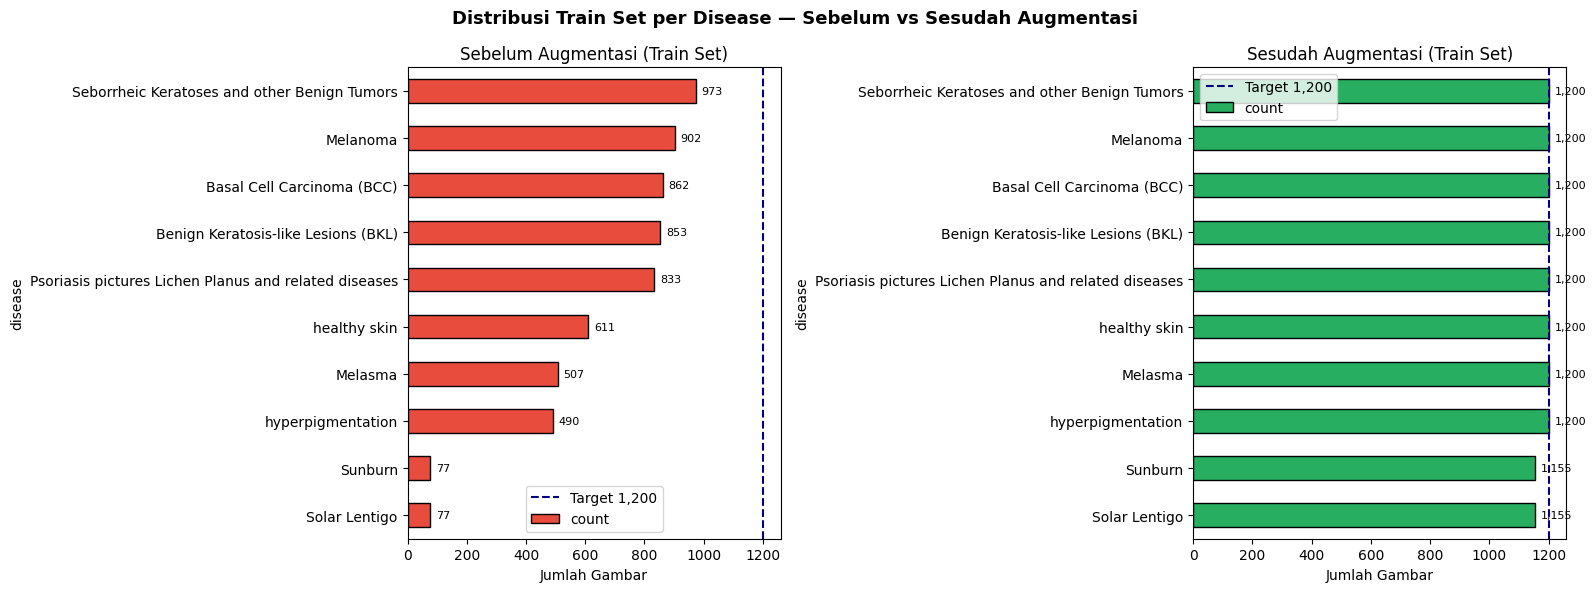

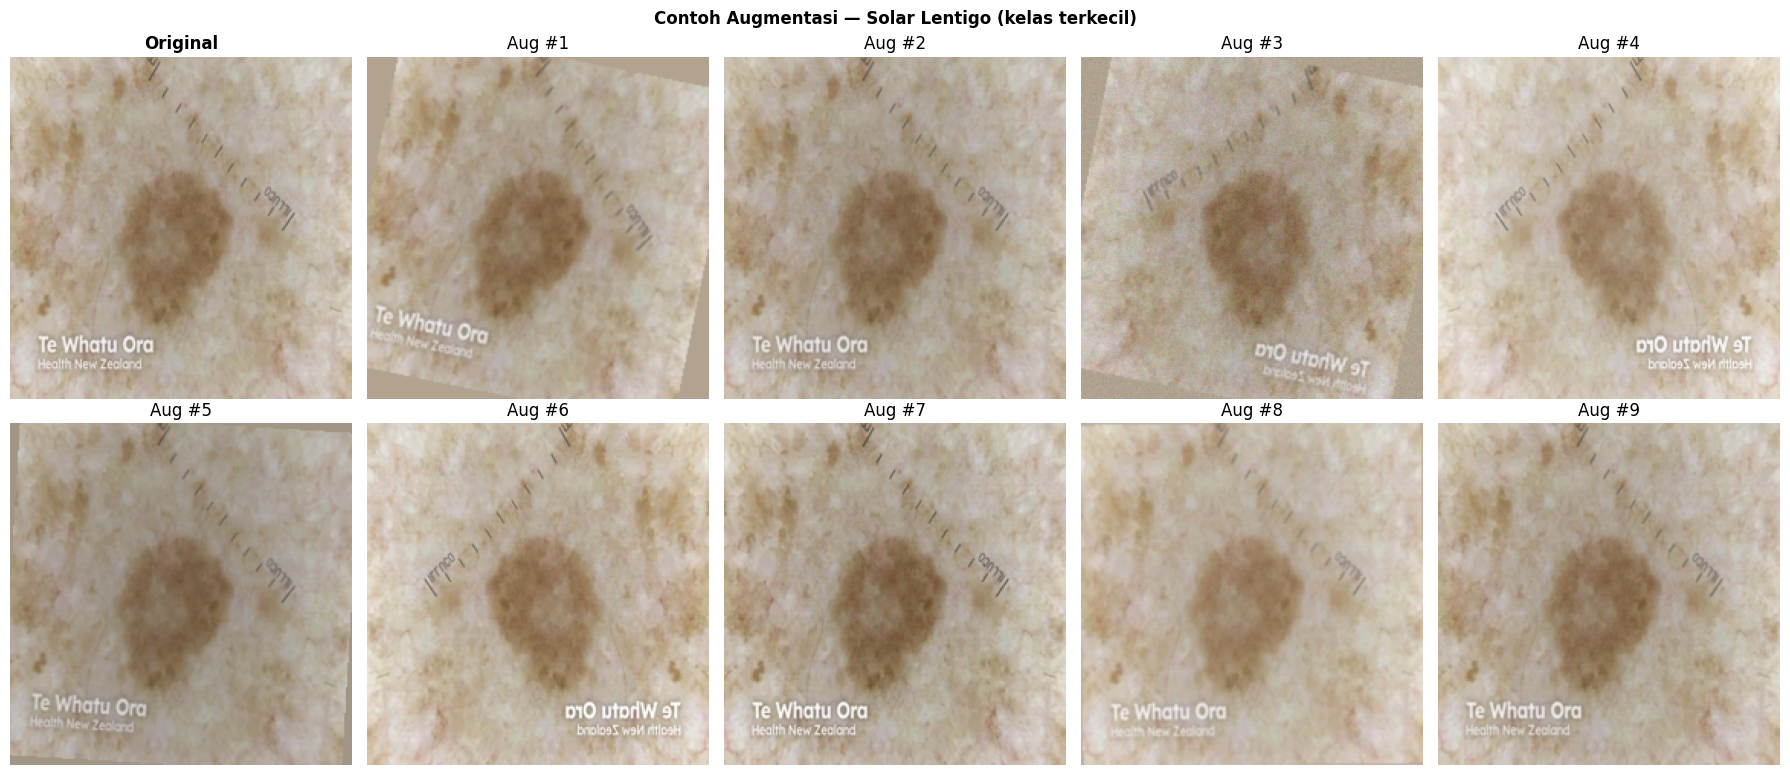

In [39]:
# ── Visualisasi distribusi sebelum vs sesudah augmentasi ─────────────
train_df_aug = pd.concat([train_df.assign(is_augmented=False), aug_df],
                          ignore_index=True)

before = train_df['disease'].value_counts().sort_values()
after  = train_df_aug['disease'].value_counts().reindex(before.index)

summary = pd.DataFrame({'Sebelum': before, 'Sesudah': after})
summary['Ditambah'] = summary['Sesudah'] - summary['Sebelum']
print("=== Distribusi per Disease: Sebelum vs Sesudah Augmentasi ===")
print(summary.to_string())
print(f"\nTotal train sebelum : {before.sum():,}")
print(f"Total train sesudah : {after.sum():,}")
print(f"Gambar augmentasi   : {len(aug_df):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_before = ['#e74c3c' if c < TARGET_PER_DISEASE else '#95a5a6' for c in before.values]
colors_after  = ['#27ae60' for _ in after.values]

before.plot(kind='barh', ax=axes[0], color=colors_before, edgecolor='black')
axes[0].axvline(TARGET_PER_DISEASE, color='navy', linestyle='--', linewidth=1.5,
                label=f'Target {TARGET_PER_DISEASE:,}')
axes[0].set_title("Sebelum Augmentasi (Train Set)", fontsize=12)
axes[0].set_xlabel("Jumlah Gambar")
axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f"{int(bar.get_width()):,}", va='center', fontsize=8)

after.plot(kind='barh', ax=axes[1], color=colors_after, edgecolor='black')
axes[1].axvline(TARGET_PER_DISEASE, color='navy', linestyle='--', linewidth=1.5,
                label=f'Target {TARGET_PER_DISEASE:,}')
axes[1].set_title("Sesudah Augmentasi (Train Set)", fontsize=12)
axes[1].set_xlabel("Jumlah Gambar")
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f"{int(bar.get_width()):,}", va='center', fontsize=8)

plt.suptitle("Distribusi Train Set per Disease — Sebelum vs Sesudah Augmentasi",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Contoh visual augmentasi dari kelas terkecil
smallest_disease = before.idxmin()
sample_src = train_df[train_df['disease'] == smallest_disease].sample(1).iloc[0]
orig = Image.open(sample_src['filepath']).convert("RGB").resize((224, 224))

fig2, axes2 = plt.subplots(2, 5, figsize=(18, 8))
axes2[0, 0].imshow(orig); axes2[0, 0].set_title("Original", fontweight='bold')
axes2[0, 0].axis('off')
for idx, ax in enumerate(axes2.flatten()[1:], 1):
    ax.imshow(augment_image(orig.copy()))
    ax.set_title(f"Aug #{idx}"); ax.axis('off')
plt.suptitle(f"Contoh Augmentasi — {smallest_disease} (kelas terkecil)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [40]:
# Simpan metadata augmentasi sementara (opsional — metadata lengkap ada di cell 11)
aug_meta_path = os.path.join(CLEAN_DATA_PATH, "augmented_train_metadata.csv")
aug_df.to_csv(aug_meta_path, index=False)
print(f"Metadata augmentasi disimpan → {aug_meta_path}")
print(f"Total baris : {len(aug_df):,}")
print(aug_df['disease'].value_counts().to_string())


Metadata augmentasi disimpan → D:/Analisis data cptn/clean_data\augmented_train_metadata.csv
Total baris : 5,725
disease
Solar Lentigo                                            1078
Sunburn                                                  1078
hyperpigmentation                                         710
Melasma                                                   693
healthy skin                                              589
Psoriasis pictures Lichen Planus and related diseases     367
Benign Keratosis-like Lesions (BKL)                       347
Basal Cell Carcinoma (BCC)                                338
Melanoma                                                  298
Seborrheic Keratoses and other Benign Tumors              227


## 9. Membuat Folder Clean Data

In [41]:
# Buat semua folder clean_data (train/val/test × severity × disease)
# CLEAN_DATA_PATH sudah didefinisikan di cell konfigurasi augmentasi

for split_name in ['train', 'val', 'test']:
    for severity in df['severity'].unique():
        for disease in df[df['severity'] == severity]['disease'].unique():
            folder_path = os.path.join(
                CLEAN_DATA_PATH, split_name,
                str(severity).strip(), str(disease).strip()
            )
            os.makedirs(folder_path, exist_ok=True)

print(f"Folder clean data berhasil dibuat di:")
print(f"  {CLEAN_DATA_PATH}")


Folder clean data berhasil dibuat di:
  D:/Analisis data cptn/clean_data


## 10. Export Gambar ke Clean Data

In [42]:
# ── Export semua gambar ke clean_data ────────────────────────────────
# Train  : original (train_df) + augmented (aug_df) → digabung di train/
# Val    : original saja (val_df)
# Test   : original saja (test_df)
# Augmented images SUDAH ada di CLEAN_DATA_PATH/train/ dari cell sebelumnya.
# Cell ini mengeksport gambar ORIGINAL untuk train, val, dan test.

def export_images(dataframe, split_name, out_path=CLEAN_DATA_PATH, label=""):
    count_ok, count_fail = 0, 0
    for idx, row in dataframe.iterrows():
        try:
            if pd.isna(row['disease']) or str(row['disease']).strip() == "":
                continue

            img = Image.open(row['filepath']).convert("RGB").resize((224, 224))

            save_path = os.path.join(
                out_path,
                split_name,
                str(row['severity']).strip(),
                str(row['disease']).strip(),
                row['filename']
            )
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            img.save(save_path)
            count_ok += 1

        except Exception as e:
            count_fail += 1
            print(f"  ✗ Failed: {row['filepath']} → {e}")

    tag = f" [{label}]" if label else ""
    print(f"  {split_name}{tag}: {count_ok:,} berhasil, {count_fail} gagal")

print(f"=== Export ke {CLEAN_DATA_PATH} ===\n")

print("Mengeksport gambar original...")
export_images(train_df, 'train', label='original train')
export_images(val_df,   'val',   label='original val')
export_images(test_df,  'test',  label='original test')

print()
print(f"Gambar augmentasi train sudah tersimpan dari langkah sebelumnya.")
print(f"  Folder : {CLEAN_DATA_PATH}/train/")
print(f"  Jumlah : {len(aug_df):,} gambar")

print()
print("=== Isi clean_data/train/ per disease (original + augmented) ===")
train_dir = os.path.join(CLEAN_DATA_PATH, 'train')
if os.path.isdir(train_dir):
    for sev in sorted(os.listdir(train_dir)):
        sev_path = os.path.join(train_dir, sev)
        if not os.path.isdir(sev_path): continue
        for dis in sorted(os.listdir(sev_path)):
            dis_path = os.path.join(sev_path, dis)
            if not os.path.isdir(dis_path): continue
            files    = [f for f in os.listdir(dis_path)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
            aug_cnt  = sum(1 for f in files if f.startswith('aug_'))
            orig_cnt = len(files) - aug_cnt
            print(f"  {sev}/{dis}: {len(files):,} total "
                  f"({orig_cnt:,} original + {aug_cnt:,} augmented)")
else:
    print("  (folder belum ada — jalankan dulu)")


=== Export ke D:/Analisis data cptn/clean_data ===

Mengeksport gambar original...
  train [original train]: 6,185 berhasil, 0 gagal
  val [original val]: 1,326 berhasil, 0 gagal
  test [original test]: 1,326 berhasil, 0 gagal

Gambar augmentasi train sudah tersimpan dari langkah sebelumnya.
  Folder : D:/Analisis data cptn/clean_data/train/
  Jumlah : 5,725 gambar

=== Isi clean_data/train/ per disease (original + augmented) ===
  Normal/healthy skin: 1,200 total (611 original + 589 augmented)
  Ringan/Benign Keratosis-like Lesions (BKL): 2,052 total (1,705 original + 347 augmented)
  Ringan/Solar Lentigo: 1,182 total (104 original + 1,078 augmented)
  Ringan/hyperpigmentation: 1,347 total (637 original + 710 augmented)
  Sedang/Melasma: 1,354 total (661 original + 693 augmented)
  Sedang/Psoriasis pictures Lichen Planus and related diseases: 1,442 total (1,075 original + 367 augmented)
  Sedang/Sunburn: 1,181 total (103 original + 1,078 augmented)
  Terparah/Basal Cell Carcinoma (BCC

## 11. Export Metadata Final

In [43]:
# ── Export metadata final ─────────────────────────────────────────────
os.makedirs(CLEAN_DATA_PATH, exist_ok=True)

# Gabungkan metadata train original + augmented
train_df_combined = pd.concat(
    [train_df.assign(is_augmented=False),
     aug_df[['severity','disease','filename','filepath',
             'width','height','format','mode','is_augmented']]],
    ignore_index=True
)
all_df = pd.concat([train_df_combined, val_df.assign(is_augmented=False), test_df.assign(is_augmented=False)],
                   ignore_index=True)

# Simpan metadata
train_df_combined.to_csv(
    os.path.join(CLEAN_DATA_PATH, "train_metadata.csv"), index=False
)
val_df.to_csv(
    os.path.join(CLEAN_DATA_PATH, "val_metadata.csv"),   index=False
)
test_df.to_csv(
    os.path.join(CLEAN_DATA_PATH, "test_metadata.csv"),  index=False
)
all_df.to_csv(
    os.path.join(CLEAN_DATA_PATH, "all_metadata.csv"),  index=False
)

print("=== Metadata berhasil disimpan ===")
print(f"  train_metadata.csv  : {len(train_df_combined):,} baris "
      f"({len(train_df):,} original + {len(aug_df):,} augmented)")
print(f"  val_metadata.csv    : {len(val_df):,} baris")
print(f"  test_metadata.csv   : {len(test_df):,} baris")
print(f"  all_metadata.csv    : {len(all_df):,} baris")
print()
print("=== Distribusi disease di train_metadata (original + aug) ===")
dist = train_df_combined.groupby(['disease','is_augmented']).size().unstack(fill_value=0)
if True  in dist.columns: dist = dist.rename(columns={True: 'augmented', False: 'original'})
dist['total'] = dist.sum(axis=1)
print(dist.sort_values('total', ascending=False).to_string())


=== Metadata berhasil disimpan ===
  train_metadata.csv  : 11,910 baris (6,185 original + 5,725 augmented)
  val_metadata.csv    : 1,326 baris
  test_metadata.csv   : 1,326 baris
  all_metadata.csv    : 14,562 baris

=== Distribusi disease di train_metadata (original + aug) ===
is_augmented                                           original  augmented  total
disease                                                                          
Basal Cell Carcinoma (BCC)                                  862        338   1200
Benign Keratosis-like Lesions (BKL)                         853        347   1200
Melanoma                                                    902        298   1200
Melasma                                                     507        693   1200
Psoriasis pictures Lichen Planus and related diseases       833        367   1200
Seborrheic Keratoses and other Benign Tumors                973        227   1200
hyperpigmentation                                           490  

## 12. Final Check

In [44]:
print("=" * 50)
print("FINAL CHECK")
print("=" * 50)
print(f"Train  (original)  : {len(train_df):,}")
print(f"Train  (augmented) : {len(aug_df):,}")
print(f"Train  (combined)  : {len(train_df_combined):,}")
print(f"Val                : {len(val_df):,}")
print(f"Test               : {len(test_df):,}")
print()
print(f"Semua file ada di  : {CLEAN_DATA_PATH}")
print(f"  train/ → original + augmented (digabung per folder disease)")
print(f"  val/   → original saja")
print(f"  test/  → original saja")


FINAL CHECK
Train  (original)  : 6,185
Train  (augmented) : 5,725
Train  (combined)  : 11,910
Val                : 1,326
Test               : 1,326

Semua file ada di  : D:/Analisis data cptn/clean_data
  train/ → original + augmented (digabung per folder disease)
  val/   → original saja
  test/  → original saja


## 12b. Feature Engineering
Mengekstrak fitur numerik dari gambar (brightness, contrast, saturation) untuk mendapatkan informasi tambahan yang berguna bagi model.

In [45]:
from scipy.ndimage import convolve

def extract_features(filepath, size=(64, 64)):
    """Ekstrak fitur statistik visual dari gambar."""
    try:
        with Image.open(filepath) as img:
            img_rgb = img.convert("RGB").resize(size)
            arr = np.array(img_rgb)

            brightness  = round(float(arr.mean()), 3)
            contrast    = round(float(arr.std()), 3)
            saturation  = round(float(arr.max(axis=2).mean() - arr.min(axis=2).mean()), 3)

            gray = np.array(img_rgb.convert("L"), dtype=float)
            laplacian = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])
            sharpness = round(float(convolve(gray, laplacian).var()), 3)

            return brightness, contrast, saturation, sharpness
    except:
        return None, None, None, None

print("Memulai feature engineering...")
print("(Menggunakan sample 1000 gambar untuk efisiensi)")

sample_fe = df.sample(min(1000, len(df)), random_state=42).copy()

sample_fe[['brightness','contrast','saturation','sharpness']] = sample_fe['filepath'].apply(
    lambda p: pd.Series(extract_features(p))
)

sample_fe = sample_fe.dropna(subset=['brightness'])
print(f"Feature engineering selesai: {len(sample_fe)} gambar")
sample_fe[['severity','disease','brightness','contrast','saturation','sharpness']].head()

Memulai feature engineering...
(Menggunakan sample 1000 gambar untuk efisiensi)
Feature engineering selesai: 1000 gambar


,severity,disease,brightness,contrast,saturation,sharpness
4161,Sedang,Psoriasis pictures Lichen Planus and related d...,149.470,42.968,97.027,88.218
4366,Sedang,Psoriasis pictures Lichen Planus and related d...,131.229,55.822,58.736,347.756
5981,Terparah,Basal Cell Carcinoma (BCC),54.897,78.426,4.427,698.284
6743,Terparah,Melanoma,124.814,44.586,77.195,545.874
4503,Sedang,Psoriasis pictures Lichen Planus and related d...,81.268,64.974,78.976,651.497


C:\Users\001497\AppData\Local\Temp\ipykernel_9540\3957450396.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_fe, x='severity', y=feat,
C:\Users\001497\AppData\Local\Temp\ipykernel_9540\3957450396.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_fe, x='severity', y=feat,
C:\Users\001497\AppData\Local\Temp\ipykernel_9540\3957450396.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_fe, x='severity', y=feat,
C:\Users\001497\AppData\Local\Temp\ipykernel_9540\3957450396.py:7: FutureWarning: 

Passing `p

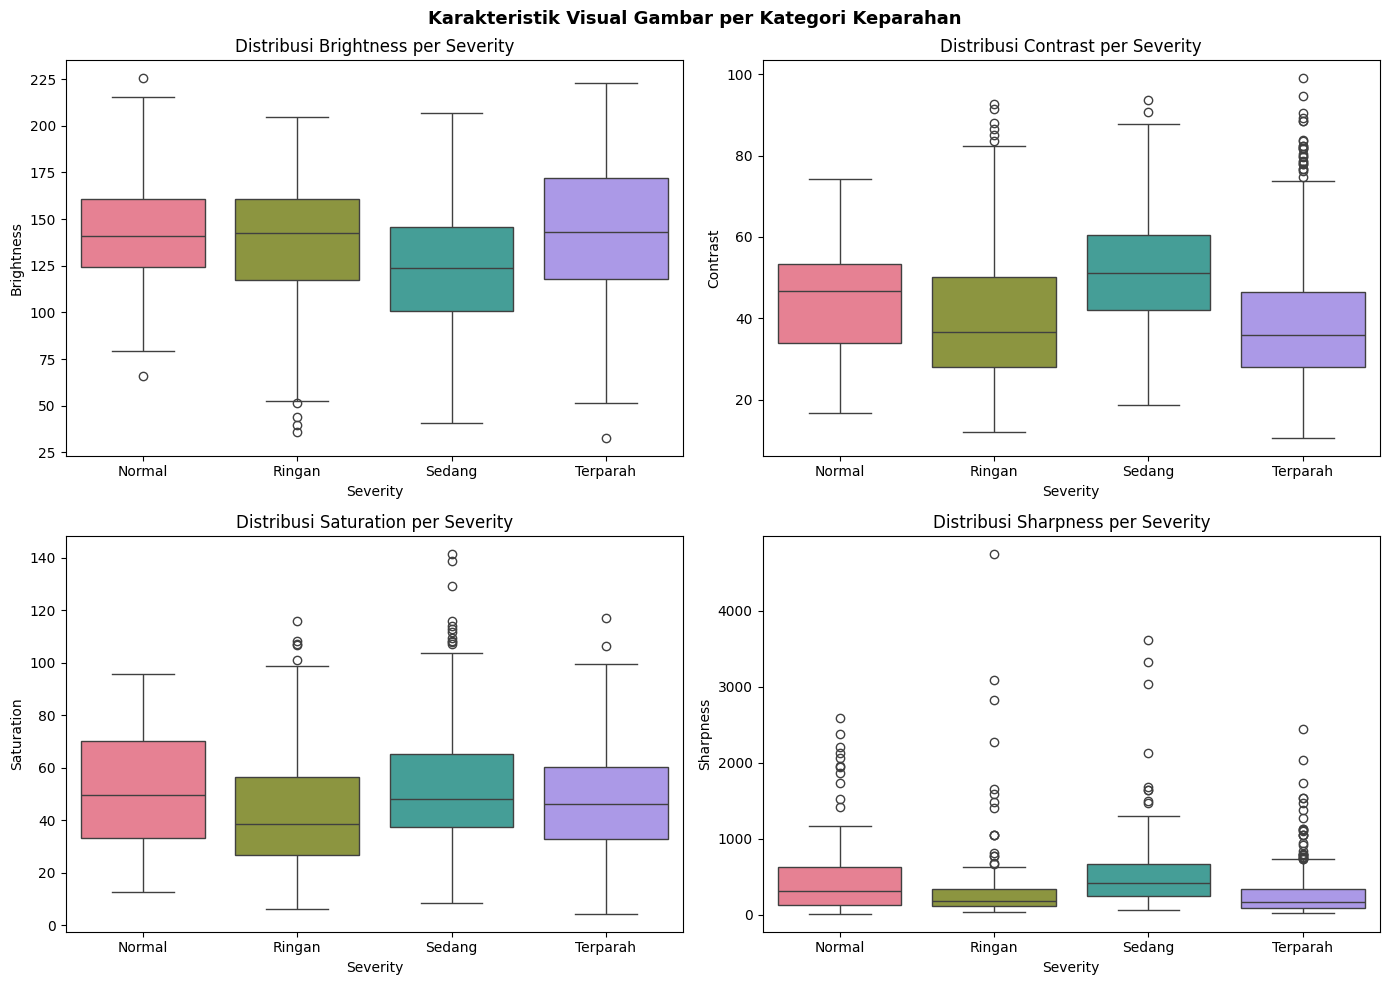

In [46]:
# Visualisasi fitur per severity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['brightness', 'contrast', 'saturation', 'sharpness']
sev_order_fe = ['Normal', 'Ringan', 'Sedang', 'Terparah']

for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=sample_fe, x='severity', y=feat,
                order=sev_order_fe, palette='husl', ax=ax)
    ax.set_title(f"Distribusi {feat.capitalize()} per Severity")
    ax.set_xlabel("Severity")
    ax.set_ylabel(feat.capitalize())

plt.suptitle("Karakteristik Visual Gambar per Kategori Keparahan", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12c. Model Readiness Check
Memastikan data sudah siap diproses oleh model sebelum diserahkan ke tim AI/ML.

In [47]:
print("=" * 50)
print("MODEL READINESS CHECKLIST")
print("=" * 50)

checks = {
    "Dataset berhasil dibaca": len(df) > 0,
    "Tidak ada missing values di label severity": df['severity'].isnull().sum() == 0,
    "Tidak ada missing values di label disease": df['disease'].isnull().sum() == 0,
    "Tidak ada duplikat filepath": df.duplicated(subset=['filepath']).sum() == 0,
    "Split train/val/test sudah dilakukan": len(train_df) > 0 and len(val_df) > 0 and len(test_df) > 0,
    "Split menggunakan stratified sampling": True,
    "Gambar akan di-resize ke 224x224": True,
    "Gambar akan dikonversi ke RGB": True,
    "Data Dictionary tersedia": True,
    "Metadata CSV tersimpan": True,
}

for item, status in checks.items():
    icon = "✅" if status else "❌"
    print(f"  {icon}  {item}")

print()
print("Distribusi split (stratified):")
print(f"  Train      : {len(train_df):,} ({len(train_df)/len(df)*100:.0f}%)")
print(f"  Validation : {len(val_df):,} ({len(val_df)/len(df)*100:.0f}%)")
print(f"  Test       : {len(test_df):,} ({len(test_df)/len(df)*100:.0f}%)")
print()
print("Rekomendasi sebelum training:")
print("  1. Normalisasi piksel ke [0.0, 1.0]")
print("  2. Augmentasi kelas Normal dan Ringan")
print("  3. Terapkan class_weight saat compile model")

MODEL READINESS CHECKLIST
  ✅  Dataset berhasil dibaca
  ✅  Tidak ada missing values di label severity
  ✅  Tidak ada missing values di label disease
  ✅  Tidak ada duplikat filepath
  ✅  Split train/val/test sudah dilakukan
  ✅  Split menggunakan stratified sampling
  ✅  Gambar akan di-resize ke 224x224
  ✅  Gambar akan dikonversi ke RGB
  ✅  Data Dictionary tersedia
  ✅  Metadata CSV tersimpan

Distribusi split (stratified):
  Train      : 6,185 (70%)
  Validation : 1,326 (15%)
  Test       : 1,326 (15%)

Rekomendasi sebelum training:
  1. Normalisasi piksel ke [0.0, 1.0]
  2. Augmentasi kelas Normal dan Ringan
  3. Terapkan class_weight saat compile model


## Insight

In [48]:
## Insight — Ringkasan Lengkap Notebook

### Ringkasan data & metadata
- Total gambar: **8.837**
- Distribusi severity:
    - Terparah : 3.911 (44.3%)
    - Ringan   : 2.029 (23.0%)
    - Sedang   : 2.025 (22.9%)
    - Normal   :   872 (9.9%)
- Top 10 penyakit (jumlah, % dari total):
    1. Seborrheic Keratoses and other Benign Tumors — 1.399 (15.8%)  
    2. Melanoma — 1.277 (14.5%)  
    3. Basal Cell Carcinoma (BCC) — 1.235 (14.0%)  
    4. Benign Keratosis-like Lesions (BKL) — 1.214 (13.7%)  
    5. Psoriasis pictures Lichen Planus and related diseases — 1.178 (13.3%)  
    6. healthy skin — 872 (9.9%)  
    7. Melasma — 732 (8.3%)  
    8. hyperpigmentation — 700 (7.9%)  
    9. Solar Lentigo — 115 (1.3%)  
 10. Sunburn — 115 (1.3%)

### Data cleaning & pipeline
- Semua gambar terdeteksi, duplicate filepath = **0**.  
- Gambar di-convert ke RGB dan di-resize ke 224×224 untuk training pipeline.  
- Metadata asli dan final disimpan (metadata_raw_dataset.csv, train/val/test metadata di clean_data).

### Split dataset
- Train (original): **6.185**  
- Validation: **1.326**  
- Test: **1.326**

### Augmentasi — hasil & catatan
- Tujuan augmentasi: ~1.200 gambar per disease di train set (TARGET_PER_DISEASE = 1200), MAX_AUG_PER_IMAGE = 15.
- Hasil augmentasi:
    - Augmented images dibuat: **5.725** (→ train combined = **11.910** baris: 6.185 original + 5.725 augmented).
    - Sebagian besar penyakit mencapai target 1.200 per disease.
    - Dua kelas sangat kecil (Solar Lentigo, Sunburn) mencapai **1.155** karena pembatasan cap per sumber (cap operasional tercapai).
    - Diversity check: maksimum penggunaan sumber ≤ cap (kontrol X augmentation per gambar).
- Augmentasi menerapkan transform probabilistik ringan (flip horizontal, rotasi ±15°, brightness/contrast/saturation jitter, blur ringan, noise kecil) untuk menjaga realisme klinis.

### Feature engineering (ringkas)
- Ekstraksi fitur numerik visual pada sample 1.000 gambar: brightness, contrast, saturation, sharpness.
- Visualisasi boxplot per severity dibuat untuk mengecek perbedaan distribusi fitur; fitur ini dapat dipakai sebagai tambahan input/metadata atau untuk analisis bias/quality control.

### Kesimpulan utama (jawaban Pertanyaan Bisnis)
- Penyakit paling dominan: **Seborrheic Keratoses and other Benign Tumors** (1.399 gambar, ~15.8%).  
- Kategori keparahan yang mendominasi: **Terparah** (3.911 gambar, ~44.3%).  
- Dataset bersifat imbalanced (Terparah vs Normal ≈ **4.5×**), perlu mitigasi (sudah ditangani sebagian via augmentasi dan class weighting).


IndentationError: unindent does not match any outer indentation level (<string>, line 20)